# Import modules

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import itertools
import os
import pickle

print('Tensorflow version:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

Tensorflow version: 2.19.0
GPUs: []


In [ ]:
!unzip -q "/content/drive/MyDrive/DeepLearning Final Project/bloodcells_dataset.zip" -d /content/

# Data Setup

In [ ]:
# Get training and validation data
BATCH_SIZE = 64
IMG_SIZE = (360, 360)

data_dir = r'/content/bloodcells_dataset'

train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=67,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=67,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

class_names = train_dataset.class_names
print(f'Class names list: {class_names}')

Found 17092 files belonging to 8 classes.
Using 13674 files for training.
Found 17092 files belonging to 8 classes.
Using 3418 files for validation.
Class names list: ['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


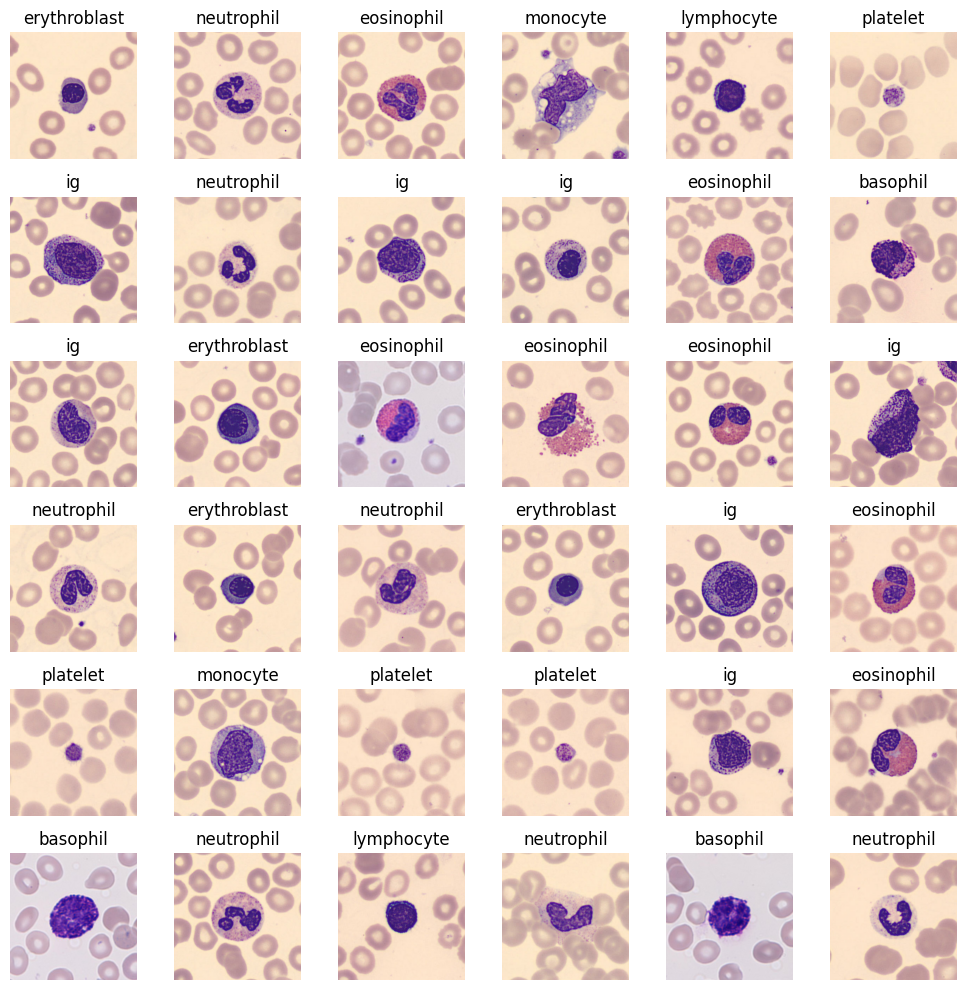

In [ ]:
# Plot example images in dataset
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    images = images[:36]
    labels = labels[:36]

    for i in range(36):
        plt.subplot(6, 6, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Validation-test (80-20) split
val_batches = tf.data.experimental.cardinality(validation_dataset)
test_dataset = validation_dataset.take(val_batches // 5)
validation_dataset = validation_dataset.skip(val_batches // 5)

print('Number of validation batches: %d' %
    tf.data.experimental.cardinality(validation_dataset))
print('Number of test batches: %d' %
    tf.data.experimental.cardinality(test_dataset))

Number of validation batches: 44
Number of test batches: 10


In [ ]:
# Autotune for quick prefetching
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

# Neural Network Setup

In [ ]:
# Rescaling layer
def rescaling_layer(model):
  rescaling_layer = { # Appropriate RGB input ranges
      "MobileNetV2": tf.keras.layers.Rescaling(1/127.5, offset=-1), # Rescale to [-1,+1]
      "EfficientNetB4": tf.keras.layers.Rescaling(1), # No rescaling
      "DenseNet201": tf.keras.layers.Rescaling(1),
      "InceptionV3": tf.keras.layers.Rescaling(1/127.5, offset=-1),
      "ResNet50V2": tf.keras.layers.Rescaling(1/127.5, offset=-1),
      "Visualization": tf.keras.layers.Rescaling(1/255) # Not a model; In case of visualization
  }
  return rescaling_layer[model]
# Resize layer
IMG_SHAPES = { # Appropriate image shapes
    "MobileNetV2": (224, 224, 3),
    "EfficientNetB4": (380, 380, 3),
    "DenseNet201": (224, 224, 3),
    "InceptionV3": (299, 299, 3),
    "ResNet50V2": (224, 224, 3)
}
def resize_layer(model):
    resize_layer = {
        "MobileNetV2": tf.keras.layers.Resizing(224, 224),
        "EfficientNetB4": tf.keras.layers.Resizing(380, 380),
        "DenseNet201": tf.keras.layers.Resizing(224, 224),
        "InceptionV3": tf.keras.layers.Resizing(299, 299),
        "ResNet50V2": tf.keras.layers.Resizing(224, 224),
        "Visualization": tf.keras.layers.Resizing(256, 256)
    }
    return resize_layer[model]

# Augmentation layer (+ Rescale and resize)
def augmentation_layer(model):
  augmentation_layer = tf.keras.Sequential([
      resize_layer(model),
      tf.keras.layers.RandomFlip('horizontal_and_vertical'),
      tf.keras.layers.RandomRotation(1),
      tf.keras.layers.RandomTranslation(0.2, 0.2),
      tf.keras.layers.RandomZoom(0.2),
      rescaling_layer(model) # Makes image at appropriate range depending on model
  ], name="augmentation")
  return augmentation_layer

In [ ]:
# Convolutional layers
from tensorflow.keras.applications import (
    MobileNetV2,
    EfficientNetB4,
    DenseNet201,
    InceptionV3,
    ResNet50V2
)

conv_layers = {
    "MobileNetV2": MobileNetV2(
        input_shape=IMG_SHAPES["MobileNetV2"],
        include_top=False,
        weights="imagenet"
    ),
    "EfficientNetB4": EfficientNetB4(
        input_shape=IMG_SHAPES["EfficientNetB4"],
        include_top=False,
        weights="imagenet"
    ),
    "DenseNet201": DenseNet201(
        input_shape=IMG_SHAPES["DenseNet201"],
        include_top=False,
        weights="imagenet"
    ),
    "InceptionV3": InceptionV3(
        input_shape=IMG_SHAPES["InceptionV3"],
        include_top=False,
        weights="imagenet"
    ),
    "ResNet50V2": ResNet50V2(
        input_shape=IMG_SHAPES["ResNet50V2"],
        include_top=False,
        weights="imagenet"
    ),
}

# Freeze convolutional bases and show parameter count
for name, conv_base in conv_layers.items():
    conv_base.trainable = False
    print(f"{name}: {conv_base.count_params():,} params")

MobileNetV2: 2,257,984 params
EfficientNetB4: 17,673,823 params
DenseNet201: 18,321,984 params
InceptionV3: 21,802,784 params
ResNet50V2: 23,564,800 params


In [ ]:
# Prediction layer
def prediction_layer(model):
  prediction_layer = tf.keras.Sequential([
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(8, activation="softmax")
  ], name="prediction_layer")
  return prediction_layer

In [ ]:
# Compile to complete classification model
def create_model(model):
  inputs = tf.keras.Input(shape=IMG_SIZE+(3,))
  x = augmentation_layer(model)(inputs)
  x = conv_layers[model](x, training=False)
  outputs = prediction_layer(model)(x)

  model = tf.keras.Model(inputs, outputs)
  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
  )
  return model

In [ ]:
# Example: MobileNetV2 model
model_MobileNetV2 = create_model('DenseNet201')
model_MobileNetV2.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 360, 360, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet201 (Functional)        │ (None, 7, 7, 1920)     │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction_layer (Sequential)   │ (None, 8)              │       254,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,576,584 (70.86 MB)

 Trainable params: 250,760 (979.53 KB)

 Non-trainable params: 18,325,824 (69.91 MB)

# AI TRAINING SECTION (and save)

In [ ]:
def train_model_and_save(model_name):
  print(f"=== Training {model_name} ===")

  tf.keras.backend.clear_session()
  model = create_model(model_name)
  history = model.fit(
    train_dataset,
    epochs=15,
    validation_data=validation_dataset
  )

  # Save model and history
  base_path = r'/content/drive/MyDrive/DeepLearning Final Project/models'
  os.makedirs(base_path, exist_ok=True)

  model.save(rf'{base_path}/{model_name}.keras')
  with open(rf'{base_path}/{model_name}_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

In [ ]:
train_model_and_save('MobileNetV2')

=== Training MobileNetV2 ===
Epoch 1/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 44s 174ms/step - accuracy: 0.6109 - loss: 1.1621 - val_accuracy: 0.8125 - val_loss: 0.7057
Epoch 2/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 38s 175ms/step - accuracy: 0.8141 - loss: 0.5694 - val_accuracy: 0.8481 - val_loss: 0.4814
Epoch 3/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 36s 168ms/step - accuracy: 0.8443 - loss: 0.4668 - val_accuracy: 0.8812 - val_loss: 0.3787
Epoch 4/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 38s 177ms/step - accuracy: 0.8675 - loss: 0.4047 - val_accuracy: 0.8891 - val_loss: 0.3461
Epoch 5/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 41s 193ms/step - accuracy: 0.8779 - loss: 0.3675 - val_accuracy: 0.8960 - val_loss: 0.3064
Epoch 6/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 37s 172ms/step - accuracy: 0.8858 - loss: 0.3361 - val_accuracy: 0.9078 - val_loss: 0.2811
Epoch 7/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 38s 178ms/step - accuracy: 0.8943 - loss: 0.3167 - val_accuracy: 0.9093 - val_loss: 0.2726
Epoch 8/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 40s 187ms/step

In [ ]:
train_model_and_save('EfficientNetB4')

=== Training EfficientNetB4 ===
Epoch 1/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 311s 1s/step - accuracy: 0.5273 - loss: 1.3734 - val_accuracy: 0.7549 - val_loss: 1.1306
Epoch 2/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.7331 - loss: 0.7947 - val_accuracy: 0.8416 - val_loss: 0.5764
Epoch 3/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.7850 - loss: 0.6377 - val_accuracy: 0.8769 - val_loss: 0.4021
Epoch 4/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.8136 - loss: 0.5484 - val_accuracy: 0.8898 - val_loss: 0.3471
Epoch 5/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.8363 - loss: 0.4950 - val_accuracy: 0.9053 - val_loss: 0.3099
Epoch 6/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.8451 - loss: 0.4585 - val_accuracy: 0.9089 - val_loss: 0.3014
Epoch 7/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - accuracy: 0.8574 - loss: 0.4299 - val_accuracy: 0.9161 - val_loss: 0.2769
Epoch 8/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - accuracy: 

In [ ]:
train_model_and_save('DenseNet201')

=== Training DenseNet201 ===
Epoch 1/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 147s 573ms/step - accuracy: 0.5047 - loss: 1.3858 - val_accuracy: 0.6569 - val_loss: 1.0671
Epoch 2/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 114s 533ms/step - accuracy: 0.6888 - loss: 0.9053 - val_accuracy: 0.7037 - val_loss: 0.8500
Epoch 3/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 114s 533ms/step - accuracy: 0.7432 - loss: 0.7405 - val_accuracy: 0.7394 - val_loss: 0.7545
Epoch 4/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 113s 530ms/step - accuracy: 0.7825 - loss: 0.6551 - val_accuracy: 0.7516 - val_loss: 0.6989
Epoch 5/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 114s 532ms/step - accuracy: 0.8016 - loss: 0.5909 - val_accuracy: 0.7700 - val_loss: 0.6689
Epoch 6/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 114s 534ms/step - accuracy: 0.8057 - loss: 0.5642 - val_accuracy: 0.7880 - val_loss: 0.6243
Epoch 7/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 142s 535ms/step - accuracy: 0.8130 - loss: 0.5439 - val_accuracy: 0.7797 - val_loss: 0.6200
Epoch 8/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 114s 53

In [ ]:
train_model_and_save('InceptionV3')

=== Training InceptionV3 ===
Epoch 1/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 100s 410ms/step - accuracy: 0.5635 - loss: 1.2503 - val_accuracy: 0.7840 - val_loss: 0.8915
Epoch 2/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 79s 369ms/step - accuracy: 0.7581 - loss: 0.7116 - val_accuracy: 0.8495 - val_loss: 0.5056
Epoch 3/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 79s 368ms/step - accuracy: 0.8044 - loss: 0.5835 - val_accuracy: 0.8722 - val_loss: 0.4021
Epoch 4/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 79s 369ms/step - accuracy: 0.8297 - loss: 0.5135 - val_accuracy: 0.8870 - val_loss: 0.3497
Epoch 5/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 79s 370ms/step - accuracy: 0.8427 - loss: 0.4649 - val_accuracy: 0.8967 - val_loss: 0.3257
Epoch 6/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 79s 369ms/step - accuracy: 0.8498 - loss: 0.4449 - val_accuracy: 0.9039 - val_loss: 0.2986
Epoch 7/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 79s 369ms/step - accuracy: 0.8619 - loss: 0.4090 - val_accuracy: 0.9078 - val_loss: 0.2817
Epoch 8/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 79s 370ms/ste

In [ ]:
train_model_and_save('ResNet50V2')

=== Training ResNet50V2 ===
Epoch 1/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 66s 265ms/step - accuracy: 0.5279 - loss: 1.3758 - val_accuracy: 0.7156 - val_loss: 0.9766
Epoch 2/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 55s 256ms/step - accuracy: 0.7470 - loss: 0.7750 - val_accuracy: 0.8089 - val_loss: 0.6017
Epoch 3/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 56s 261ms/step - accuracy: 0.7942 - loss: 0.6245 - val_accuracy: 0.8423 - val_loss: 0.4840
Epoch 4/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 55s 259ms/step - accuracy: 0.8153 - loss: 0.5467 - val_accuracy: 0.8557 - val_loss: 0.4233
Epoch 5/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 56s 260ms/step - accuracy: 0.8288 - loss: 0.5020 - val_accuracy: 0.8668 - val_loss: 0.3852
Epoch 6/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 56s 262ms/step - accuracy: 0.8427 - loss: 0.4586 - val_accuracy: 0.8726 - val_loss: 0.3723
Epoch 7/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 59s 274ms/step - accuracy: 0.8496 - loss: 0.4441 - val_accuracy: 0.8744 - val_loss: 0.3553
Epoch 8/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 82s 275ms/step 

# Train-Validation-Test performances

In [ ]:
# Load model and history
base_path = r'/content/drive/MyDrive/DeepLearning Final Project/models'

def load_model_and_history(model_name):
    # Load model
    model_path = os.path.join(base_path, f"{model_name}.keras")
    model = tf.keras.models.load_model(model_path)

    # Load history
    history_path = os.path.join(base_path, f"{model_name}_history.pkl")
    with open(history_path, 'rb') as f:
        history = pickle.load(f)

    return model, history

In [ ]:
# Load models
model_names = [
    "MobileNetV2",
    "EfficientNetB4",
    "DenseNet201",
    "InceptionV3",
    "ResNet50V2"
]
m = {}
h = {}

for name in model_names:
  print(f'Loading {name}...')
  model, history = load_model_and_history(name)
  m[name] = model
  h[name] = history

Loading MobileNetV2...
Loading EfficientNetB4...
Loading DenseNet201...
Loading InceptionV3...
Loading ResNet50V2...


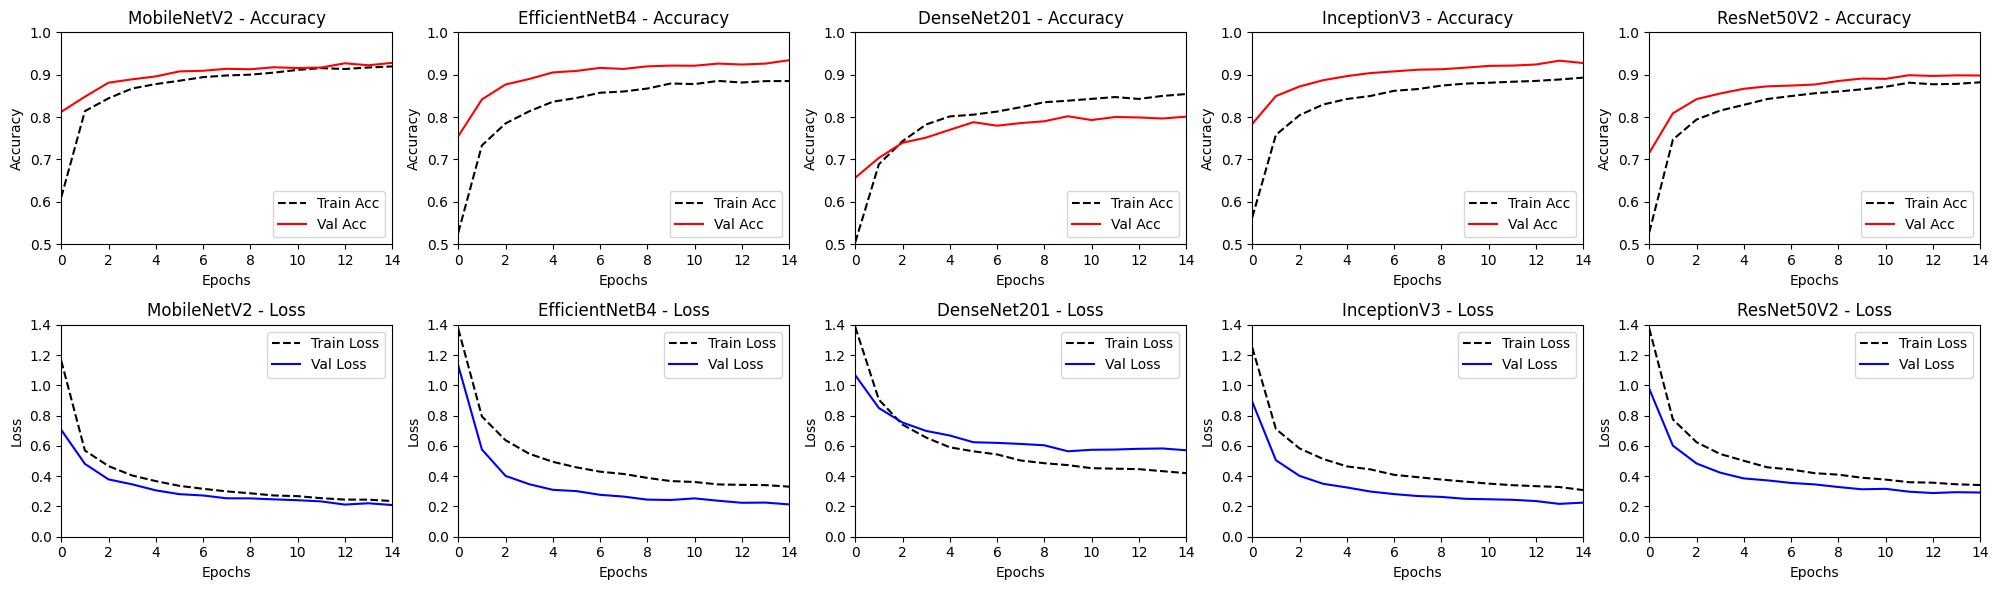

In [ ]:
# Plot history
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
for i, name in enumerate(model_names):
    history = h[name]

    # Handle possible key variations
    acc = history.get('accuracy') or history.get('acc')
    val_acc = history.get('val_accuracy') or history.get('val_acc')
    loss = history.get('loss')
    val_loss = history.get('val_loss')

    epochs = range(len(acc))

    # --- Top row: Accuracy ---
    ax_acc = axes[0, i]
    ax_acc.plot(epochs, acc, 'k--', label='Train Acc')   # dotted black
    ax_acc.plot(epochs, val_acc, 'r-', label='Val Acc')  # solid blue
    ax_acc.set_title(f"{name} - Accuracy")
    ax_acc.set_xlabel("Epochs")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend(loc='lower right')
    ax_acc.set_xlim(0, 14)
    ax_acc.set_ylim(0.5, 1.0)

    # --- Bottom row: Loss ---
    ax_loss = axes[1, i]
    ax_loss.plot(epochs, loss, 'k--', label='Train Loss')   # dotted black
    ax_loss.plot(epochs, val_loss, 'b-', label='Val Loss')  # solid blue
    ax_loss.set_title(f"{name} - Loss")
    ax_loss.set_xlabel("Epochs")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend(loc='upper right')
    ax_loss.set_xlim(0, 14)
    ax_loss.set_ylim(0, 1.4)

plt.tight_layout()
plt.show()

Evaluating MobileNetV2...
10/10 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.9219 - loss: 0.1899
MobileNetV2 Test Accuracy: 0.9219
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step


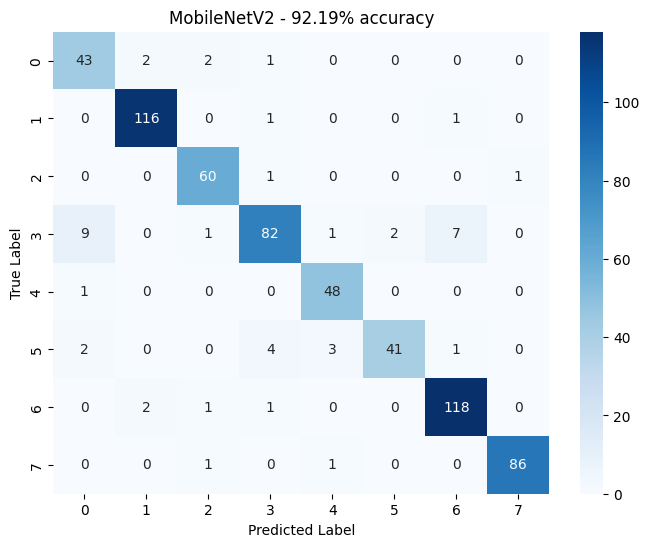

Evaluating EfficientNetB4...
10/10 ━━━━━━━━━━━━━━━━━━━━ 417s 41s/step - accuracy: 0.9453 - loss: 0.1609
EfficientNetB4 Test Accuracy: 0.9453
2/2 ━━━━━━━━━━━━━━━━━━━━ 39s 19s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 41s 20s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 41s 21s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 39s 19s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 50s 29s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 41s 21s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 40s 20s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 39s 19s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 41s 21s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 39s 20s/step


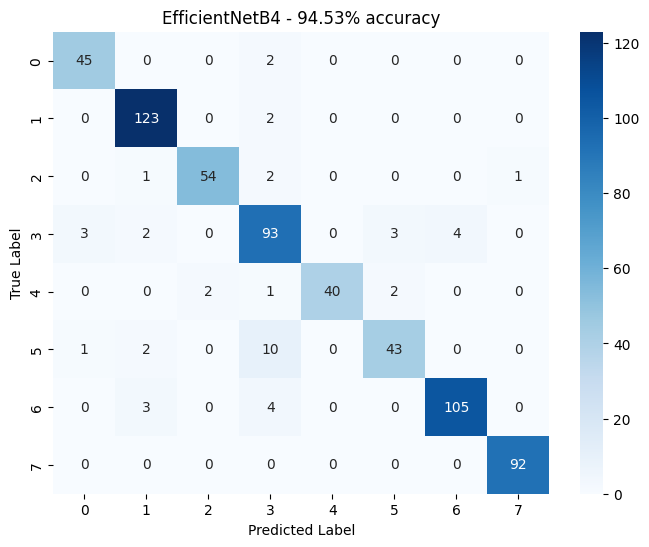

Evaluating DenseNet201...
10/10 ━━━━━━━━━━━━━━━━━━━━ 200s 18s/step - accuracy: 0.7984 - loss: 0.5533
DenseNet201 Test Accuracy: 0.7984
2/2 ━━━━━━━━━━━━━━━━━━━━ 25s 9s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 7s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 9s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 10s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 30s 19s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 9s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 8s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 7s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 7s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 9s/step


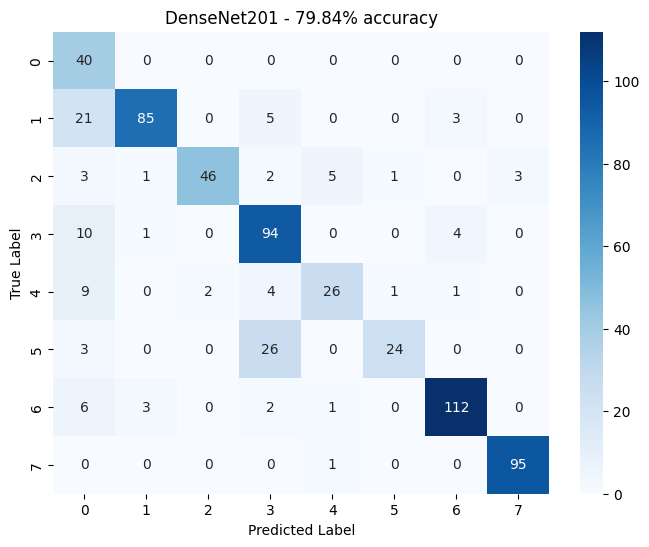

Evaluating InceptionV3...
10/10 ━━━━━━━━━━━━━━━━━━━━ 175s 17s/step - accuracy: 0.9312 - loss: 0.2113
InceptionV3 Test Accuracy: 0.9312
2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 9s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 9s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 8s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 8s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 7s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 9s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 9s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 9s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 8s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 7s/step


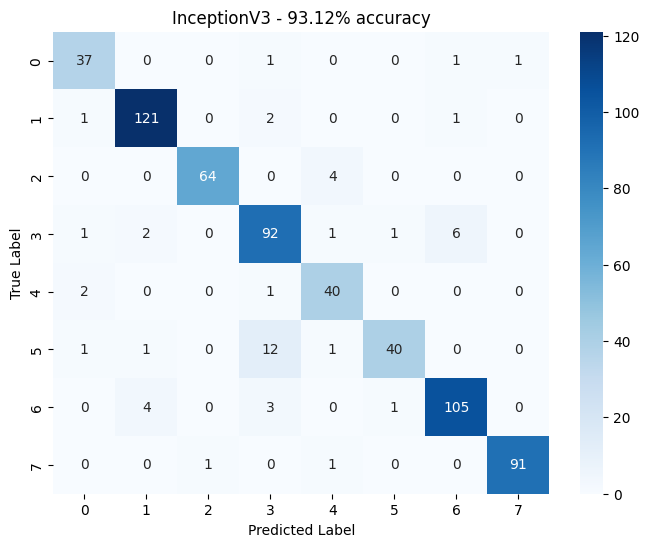

Evaluating ResNet50V2...
10/10 ━━━━━━━━━━━━━━━━━━━━ 127s 12s/step - accuracy: 0.9031 - loss: 0.2756
ResNet50V2 Test Accuracy: 0.9031
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 7s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 5s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 7s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 5s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 6s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 5s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 7s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step


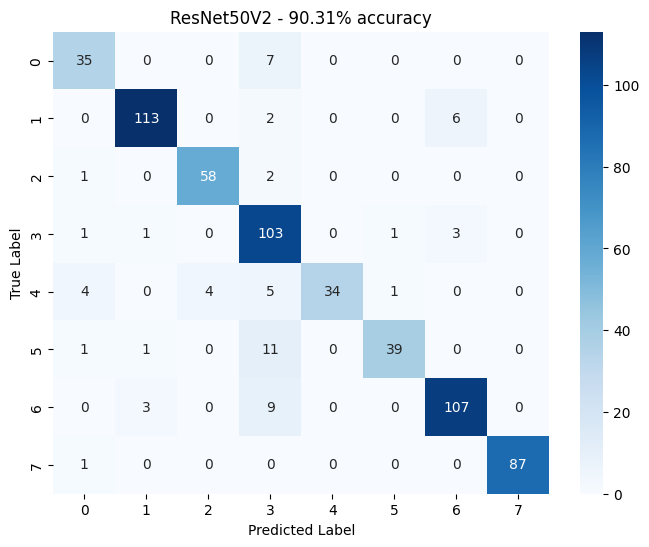

In [ ]:
results = {}
classes = class_names

for name in model_names:
    print(f"Evaluating {name}...")
    model = m[name]

    # =========================
    # 1. Evaluate (safe)
    # =========================
    loss, acc = model.evaluate(test_dataset, verbose=1)
    results[name] = acc
    print(f"{name} Test Accuracy: {acc:.4f}")

    # =========================
    # 2. Collect predictions + labels in ONE pass
    # =========================
    y_true = []
    y_pred = []

    for images, labels in test_dataset:
        preds = model.predict(images, verbose=1)

        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # =========================
    # 3. Confusion matrix
    # =========================
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{name} - {acc*100:.2f}% accuracy")
    plt.show()